In [1]:
# from cooplot import api
import cooplot as cp

In [2]:
# header, people = cp.load_csv("hih.csv", delimiter=";")
header, people = cp.load_csv("agberens.csv", delimiter=";")

In [3]:
pubs = cp.scrape(
    people,
    name_col="name",
    scholar_col="scholar_id",
    semantic_col="semantic_id",
    cache_dir="./agberens",
    drop_subtitle=False,
    fallback_semantic_if_empty=True,  # try Semantic if GS had 0 pubs
)

Scraping:   0%|          | 0/31 [00:00<?, ?it/s]

Scraping: 100%|██████████| 31/31 [00:00<00:00, 2216.22it/s]


In [ ]:
pubs = pubs.exclude_authors(["Philipp Berens"]) # the boss overwhelms the analysis

In [5]:
mats = cp.build(pubs, windows=["2016-2025"], name_col="name", group_col="group")

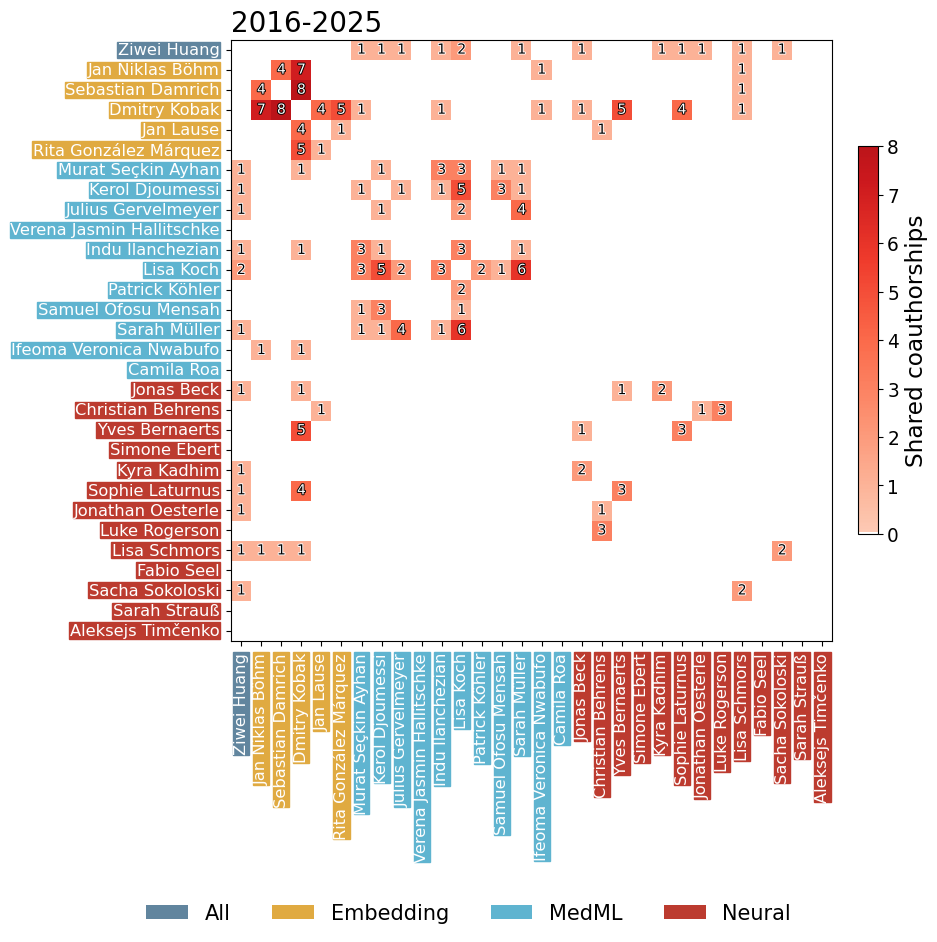

In [6]:
palette = {
    "All": "#61859e",
    "Embedding": "#e0aa41",
    "MedML": "#5fb4d0",
    "Neural": "#bc3b2f",
}
fig = cp.show(mats, group_col="group", style="heatmap", heatmap_counts=True, palette=palette, figsize=(10,10))
# fig.savefig("hai.png", dpi=300)

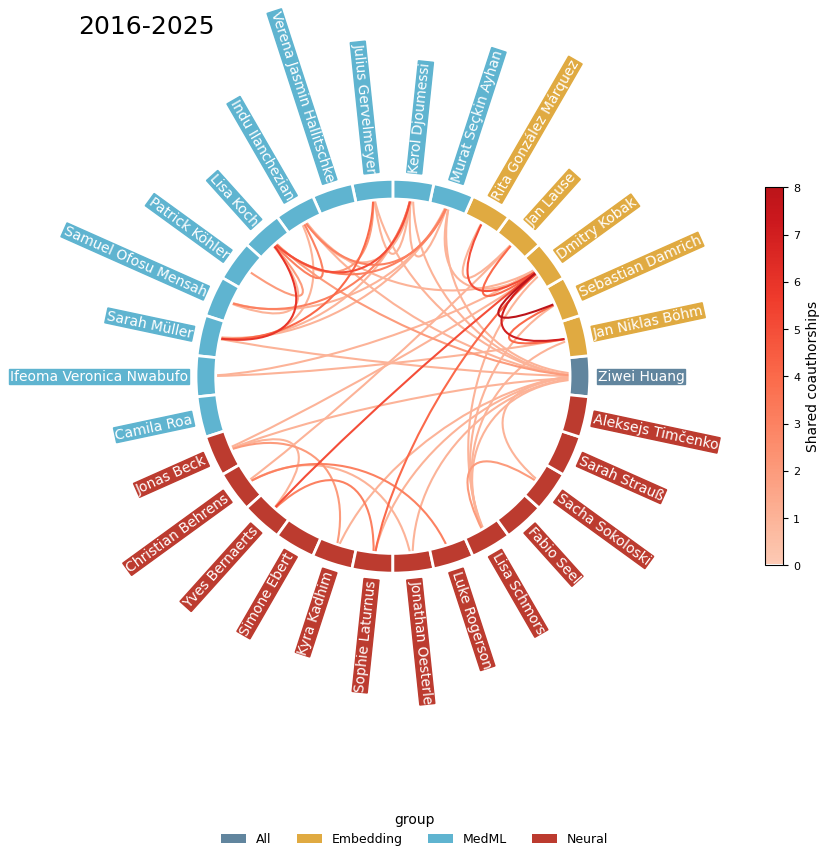

In [7]:
fig = cp.show(mats, group_col="group", style="circle", heatmap_counts=True, palette=palette)

In [8]:
grouped = cp.aggregate(pubs, name_col="name", cache_dir="./agberens-subgroup")

In [9]:
# grouped = grouped.exclude_groups()
# grouped

In [10]:
mats_grouped = cp.build(grouped, windows=["2016-2025"])

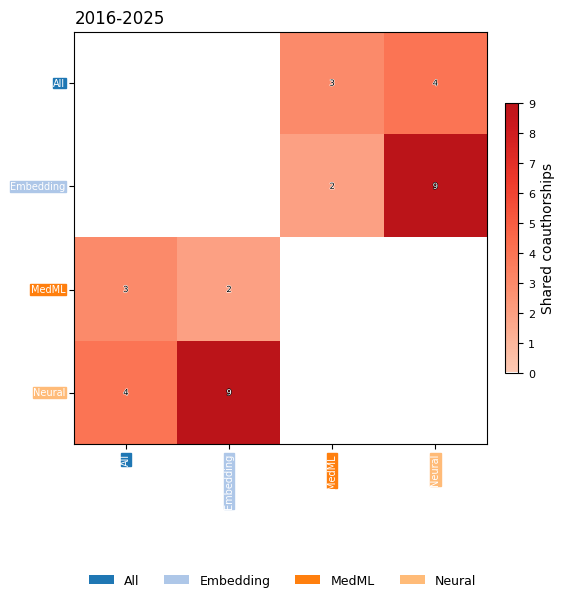

In [11]:
fig = cp.show(mats_grouped, style="heatmap", heatmap_counts=True)


In [12]:
res = cp.cross_group_publications(grouped, year_from=2016, year_to=2025)

In [13]:
res

[{'title': 'Layer 4 of mouse neocortex differs in cell types and circuit organization between sensory areas',
  'norm_title': 'layer 4 of mouse neocortex differs in cell types and circuit organization between sensory areas',
  'year': 2019,
  'groups': ['Embedding', 'Neural'],
  'authors': {'Embedding': ['Dmitry Kobak'],
   'Neural': ['Yves Bernaerts', 'Sophie Laturnus']}},
 {'title': 'A systematic evaluation of interneuron morphology representations for cell type discrimination',
  'norm_title': 'a systematic evaluation of interneuron morphology representations for cell type discrimination',
  'year': 2020,
  'groups': ['Embedding', 'Neural'],
  'authors': {'Embedding': ['Dmitry Kobak'], 'Neural': ['Sophie Laturnus']}},
 {'title': 'MorphoPy: A python package for feature extraction of neural morphologies.',
  'norm_title': 'morphopy a python package for feature extraction of neural morphologies',
  'year': 2020,
  'groups': ['All', 'Neural'],
  'authors': {'All': ['Ziwei Huang'], 'Neur